In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [82]:
files = [
    "chile_2000_2005.csv",
    "chile_2005_2010.csv",
    "chile_2010_2015.csv",
    "chile_2015_2020.csv",
    "chile_2020_2025.csv"
]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

In [83]:
df['type'].value_counts()


type
earthquake    36139
Name: count, dtype: int64

In [84]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
11441,2000-01-01 04:30:10.370000+00:00,-26.012,-68.803,105.0,4.5,mb,NaN,NaN,NaN,0.91,...,2014-11-07T01:09:14.812Z,"130 km ENE of Diego de Almagro, Chile",earthquake,NaN,NaN,NaN,15.0,reviewed,us,us
11440,2000-01-01 16:01:13.500000+00:00,-22.214,-70.191,67.2,4.4,mb,NaN,NaN,NaN,0.83,...,2014-11-07T01:09:15.804Z,"13 km S of Tocopilla, Chile",earthquake,NaN,14.1,NaN,4.0,reviewed,us,us
11439,2000-01-02 02:13:28.920000+00:00,-17.346,-69.277,161.6,3.7,mb,NaN,NaN,NaN,1.13,...,2014-11-07T01:09:15.988Z,"81 km E of Tarata, Peru",earthquake,NaN,11.4,NaN,2.0,reviewed,us,us
11438,2000-01-03 04:03:14.990000+00:00,-21.110,-68.424,134.4,4.0,mb,NaN,NaN,NaN,1.13,...,2014-11-07T01:09:16.772Z,"157 km NNE of Calama, Chile",earthquake,NaN,16.0,NaN,4.0,reviewed,us,us
11437,2000-01-06 21:37:49.760000+00:00,-18.334,-69.446,143.2,4.6,mb,NaN,NaN,NaN,0.73,...,2014-11-07T01:09:18.065Z,"Tarapaca, Chile",earthquake,NaN,8.8,NaN,7.0,reviewed,us,us


In [85]:
df.shape

(36139, 22)

In [86]:
df.dtypes

time               datetime64[ns, UTC]
latitude                       float64
longitude                      float64
depth                          float64
mag                            float64
magType                         object
nst                            float64
gap                            float64
dmin                           float64
rms                            float64
net                             object
id                              object
updated                         object
place                           object
type                            object
horizontalError                float64
depthError                     float64
magError                       float64
magNst                         float64
status                          object
locationSource                  object
magSource                       object
dtype: object

In [87]:
df.isnull().sum()

time                   0
latitude               0
longitude              0
depth                  0
mag                    0
magType                0
nst                 9684
gap                 7648
dmin               25605
rms                17381
net                    0
id                     0
updated                0
place                  4
type                   0
horizontalError    25925
depthError         20543
magError           25699
magNst             18441
status                 0
locationSource         0
magSource              0
dtype: int64

In [88]:
cols_keep = [
    'time',
    'latitude',
    'longitude',
    'depth',
    'mag',
    'magType',
    'type',
    'rms',
    'gap',
    'dmin'
]

df = df[cols_keep].copy()

In [89]:
for col in ['rms', 'gap', 'dmin']:
    df[col + '_missing'] = df[col].isna().astype(int)
df['gap'] = df['gap'].fillna(360)
df['dmin'] = df['dmin'].fillna(df['dmin'].quantile(0.95))
df['rms'] = df['rms'].fillna(df['rms'].quantile(0.95))


In [90]:
df.isnull().sum()

time            0
latitude        0
longitude       0
depth           0
mag             0
magType         0
type            0
rms             0
gap             0
dmin            0
rms_missing     0
gap_missing     0
dmin_missing    0
dtype: int64

In [91]:
df['type'].value_counts()


type
earthquake    36139
Name: count, dtype: int64

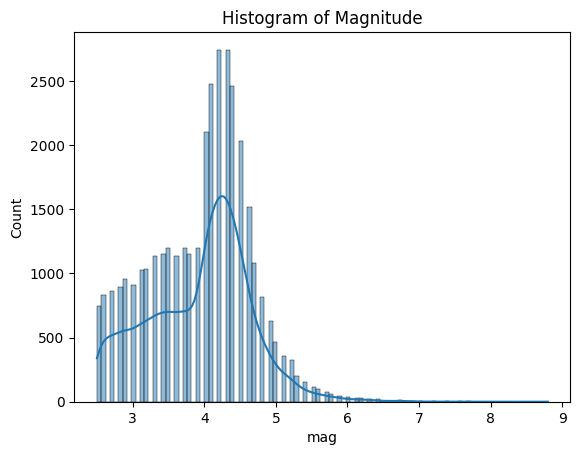

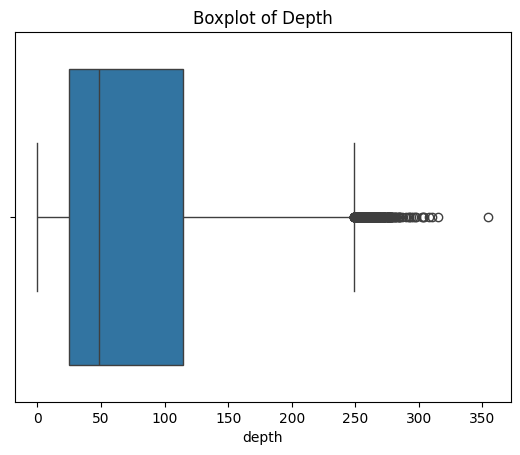

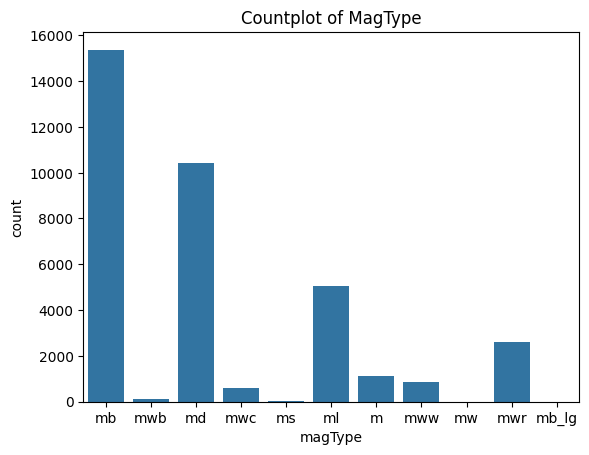

In [92]:
sns.histplot(data=df, x='mag', kde=True)
plt.title('Histogram of Magnitude')
plt.show()

sns.boxplot(data=df, x='depth')
plt.title('Boxplot of Depth')
plt.show()

sns.countplot(data=df, x='magType')
plt.title('Countplot of MagType')
plt.show()

In [93]:
df['magType'].value_counts(normalize=True)


magType
mb       0.425468
md       0.287916
ml       0.139766
mwr      0.071751
m        0.030521
mww      0.023825
mwc      0.016824
mwb      0.003680
ms       0.000138
mw       0.000083
mb_lg    0.000028
Name: proportion, dtype: float64

In [94]:
df.isnull().sum()

time            0
latitude        0
longitude       0
depth           0
mag             0
magType         0
type            0
rms             0
gap             0
dmin            0
rms_missing     0
gap_missing     0
dmin_missing    0
dtype: int64

In [95]:
df.dtypes

time            datetime64[ns, UTC]
latitude                    float64
longitude                   float64
depth                       float64
mag                         float64
magType                      object
type                         object
rms                         float64
gap                         float64
dmin                        float64
rms_missing                   int64
gap_missing                   int64
dmin_missing                  int64
dtype: object

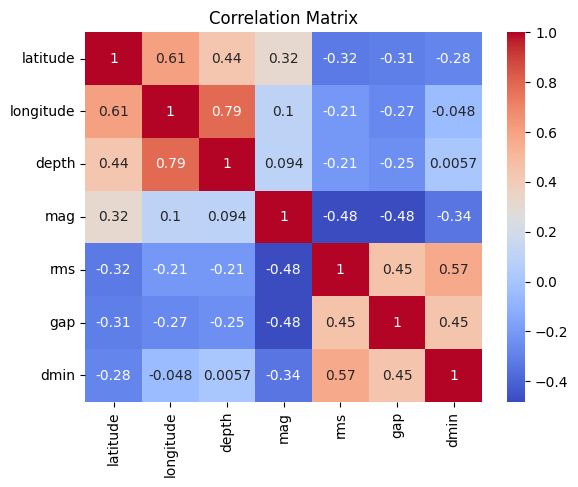

In [96]:
numeric_cols = ['latitude', 'longitude', 'depth', 'mag', 'rms', 'gap', 'dmin']

corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Statistical Analysis to test hypothesis.

Hypothesis:

Null Hypothesis (H0): There is no statistically significant relationship between earthquake magnitude, its depth, spatial location, and the time elapsed since the previous earthquake.

Alternative Hypothesis (H1): There exists a statistically significant relationship between earthquake magnitude and at least one of the following variables: depth, spatial location, or the time elapsed since the previous earthquake.

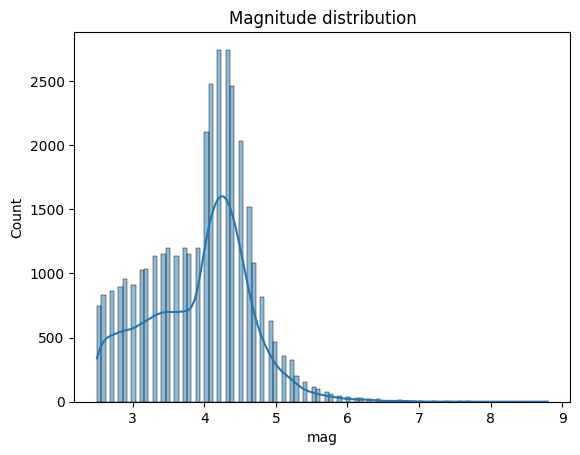

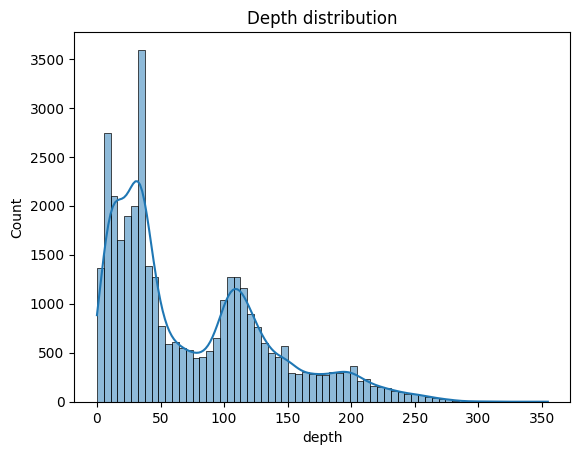

In [97]:
sns.histplot(data=df, x='mag', kde=True)
plt.title('Magnitude distribution')
plt.show()

sns.histplot(data=df, x='depth', kde=True)
plt.title('Depth distribution')
plt.show()



The distributions of magnitude and depth are non-normal and skewed, therefore non-parametric statistical tests were applied.

H0a: Earthquake magnitude is independent of earthquake depth.

In [98]:
from scipy.stats import spearmanr

rho, p = spearmanr(df['mag'], df['depth'])
print(f"Spearman rho = {rho:.3f}, p-value = {p:.5f}")


Spearman rho = 0.088, p-value = 0.00000


Although the relationship between earthquake magnitude and depth was statistically significant, the strength of the correlation was very weak (ρ = 0.088), indicating limited practical significance.

H0b: Earthquake magnitude is independent of spatial location.

In [99]:
df['lat_band'] = pd.cut(
    df['latitude'],
    bins=[-56, -42, -30, -17],
    labels=['South', 'Central', 'North']
)

In [100]:
from scipy.stats import kruskal

groups = [
    df[df['lat_band']=='South']['mag'],
    df[df['lat_band']=='Central']['mag'],
    df[df['lat_band']=='North']['mag']
]

stat, p = kruskal(*groups)

print(f"Kruskal-Wallis H = {stat:.3f}, p-value = {p:.5f}")


Kruskal-Wallis H = 6275.253, p-value = 0.00000


The Kruskal–Wallis test indicated statistically significant differences in earthquake magnitude between spatial regions, suggesting spatial heterogeneity in seismic activity.

H0c: Earthquake magnitude is independent of the time elapsed since the previous earthquake

In [101]:
df = df.sort_values('time').reset_index(drop=True)
df['inter_event_time'] = df['time'].diff().dt.total_seconds()
df = df.dropna(subset=['inter_event_time'])

rho, p = spearmanr(df['mag'], df['inter_event_time'])
print(f"Spearman rho = {rho:.3f}, p-value = {p:.5f}")


Spearman rho = 0.098, p-value = 0.00000


Although a statistically significant correlation was found between earthquake magnitude and inter-event time (ρ = 0.098, p < 0.001), the correlation is very weak, indicating limited practical significance. This suggests that the elapsed time between earthquakes has minimal influence on the magnitude of the subsequent event.

The null hypothesis was rejected, as statistically significant relationships were identified between earthquake magnitude and both depth and spatial location. However, the observed temporal correlation is likely influenced by catalog completeness effects rather than a true physical trend.

ML

In [102]:
df['rolling_mag3'] = df['mag'].rolling(window=3).mean()
df = df.dropna(subset=['inter_event_time', 'rolling_mag3'])

In [103]:
top_types = ['mb', 'md', 'ml']
df['magType'] = df['magType'].apply(lambda x: x if x in top_types else 'other')
df = pd.get_dummies(df, columns=['magType'])

In [104]:
df.columns

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'type', 'rms', 'gap',
       'dmin', 'rms_missing', 'gap_missing', 'dmin_missing', 'lat_band',
       'inter_event_time', 'rolling_mag3', 'magType_mb', 'magType_md',
       'magType_ml', 'magType_other'],
      dtype='object')

In [105]:
train_size = int(0.8 * len(df))
train = df.iloc[:train_size]
test = df.iloc[train_size:]
features = [
    'depth', 'latitude', 'longitude', 
    'inter_event_time', 'rolling_mag3',      
    'rms', 'gap', 'dmin',
    'rms_missing', 'gap_missing', 'dmin_missing',                   
    'magType_mb', 'magType_md', 'magType_ml', 'magType_other'
]

target = 'mag'

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

Random Forest Regressor

In [106]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

y_pred = rfr.predict(X_test)

In [107]:
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

RMSE: 0.251
MAE: 0.185
R²: 0.585


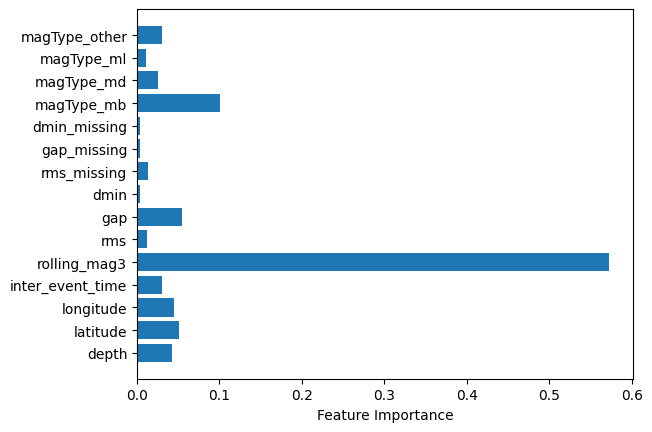

In [108]:
import matplotlib.pyplot as plt

importances = rfr.feature_importances_
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.show()


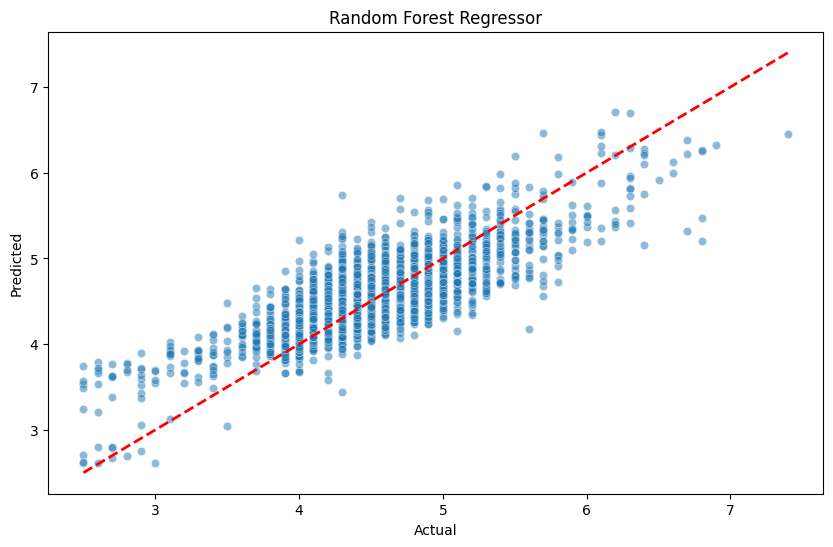

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Regressor')
plt.show()

The Random Forest regression model demonstrated a moderate ability to predict earthquake magnitudes, yielding an RMSE of 0.251 and an MAE of 0.185. While the $R^2$ value of 0.585 indicates that the model captures over a half of the target's variance, the results highlight the inherent difficulty of seismic forecasting. The discrepancy between RMSE and MAE suggests that the model is particularly sensitive to outliers, likely corresponding to rare, high-magnitude events that deviate from the average seismic patterns.

Gradient Boosting Regressor

In [110]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

In [111]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae = mean_absolute_error(y_test, y_pred_gbr)
r2 = r2_score(y_test, y_pred_gbr)

print(f"GBR RMSE: {rmse:.3f}")
print(f"GBR MAE: {mae:.3f}")
print(f"GBR R²: {r2:.3f}")


GBR RMSE: 0.257
GBR MAE: 0.192
GBR R²: 0.563


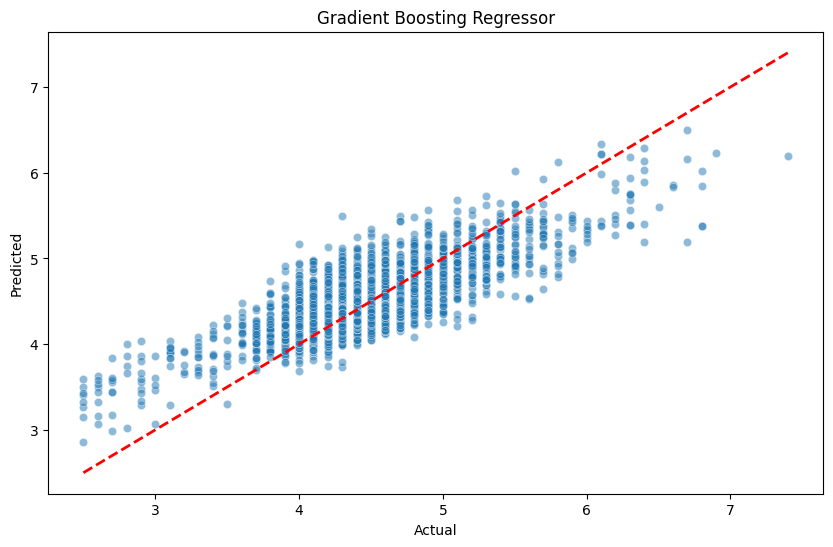

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_gbr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Gradient Boosting Regressor')
plt.show()

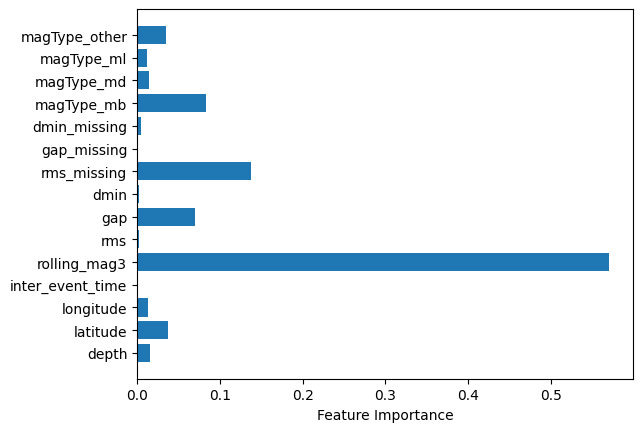

In [113]:
importances = gbr.feature_importances_
plt.barh(features, importances)
plt.xlabel("Feature Importance")
plt.show()

Both models demonstrated comparable performance, with the Random Forest (RF) regressor slightly edging out the Gradient Boosting Regressor (GBR) across all key metrics. The RF model achieved an $R^2$ of 0.585 compared to GBR’s 0.563, alongside marginally lower error rates (RMSE: 0.251 vs 0.257). This suggests that while both ensemble methods capture the dataset's patterns similarly well, the bagging approach of Random Forest provided a slightly more robust fit. Ultimately, the moderate $R^2$ values for both models highlight the inherent complexity and irreducible noise typical of seismic data, where magnitude remains challenging to predict with high precision.

| Model                       | RMSE   | MAE    | R²     |
| --------------------------- | ------ | ------ | ------ |
| Random Forest Regressor     | 0.251  | 0.185  | 0.585  |
| Gradient Boosting Regressor | 0.257  | 0.192  | 0.563  |


In conclusion, despite the marginal improvements achieved by transitioning from Random Forest to Gradient Boosting, standard regression approaches do not yield highly accurate or reliable results for earthquake magnitude prediction.

Random Forest Classifier

In [114]:
THRESHOLD = 4.5

df['target'] = (df['mag'] >= THRESHOLD).astype(int)

features = [
    'depth', 'latitude', 'longitude', 
    'inter_event_time', 'rolling_mag3',      
    'rms', 'gap', 'dmin',                   
    'magType_mb', 'magType_md', 'magType_ml' 
]

X = df[features]
y = df['target']

In [115]:
train_size = int(0.8 * len(df))

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_test = X.iloc[train_size:]
y_test = y.iloc[train_size:]

In [116]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)

rfc.fit(X_train, y_train)
y_pred_rf = rfc.predict(X_test)
y_prob_rf = rfc.predict_proba(X_test)[:, 1]


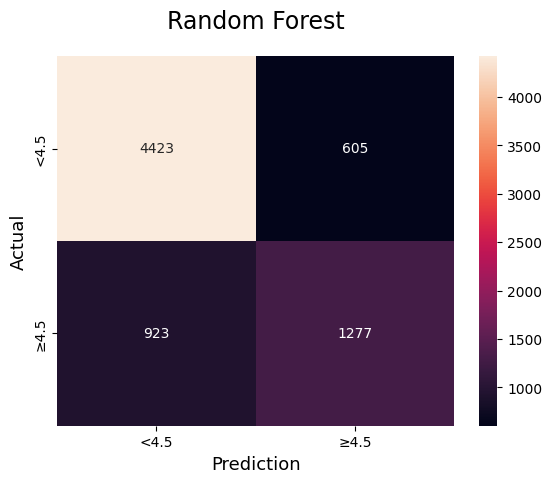

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      5028
           1       0.68      0.58      0.63      2200

    accuracy                           0.79      7228
   macro avg       0.75      0.73      0.74      7228
weighted avg       0.78      0.79      0.78      7228

ROC-AUC: 0.8358631210674767


In [117]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='g', xticklabels=['<4.5', '≥4.5'], yticklabels=['<4.5', '≥4.5'])
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Prediction', fontsize=13)
plt.title('Random Forest', fontsize=17, pad=20)
plt.show()

report = classification_report(y_test, y_pred_rf, output_dict=True)
recall_class_1_RF = report['1']['recall']
roc_auc_RF = roc_auc_score(y_test, y_prob_rf)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_RF)


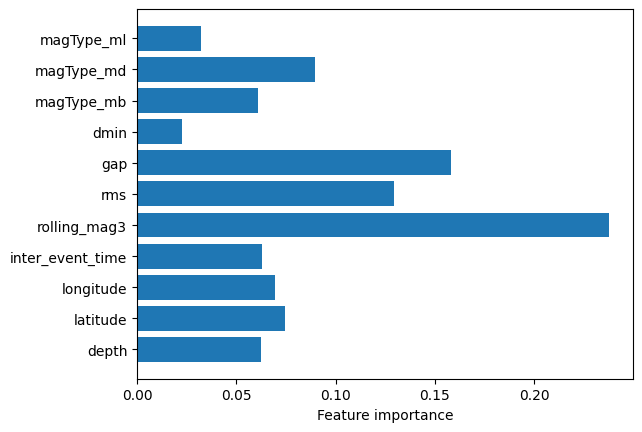

In [118]:
importances = rfc.feature_importances_
plt.barh(features, importances)
plt.xlabel("Feature importance")
plt.show()


Two magnitude thresholds were evaluated. While a threshold of 4.0 resulted in severe class imbalance and trivial classification behavior, a threshold of 4.5 provided a more balanced dataset and more meaningful evaluation of model performance.

The classification model achieved moderate performance in distinguishing higher-magnitude earthquakes (≥4.5), with a ROC-AUC of 0.84. While the model demonstrates reasonable discriminative ability, the reduced recall for the positive class indicates limitations in reliably detecting all stronger seismic events.

XGB Classifier

In [119]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

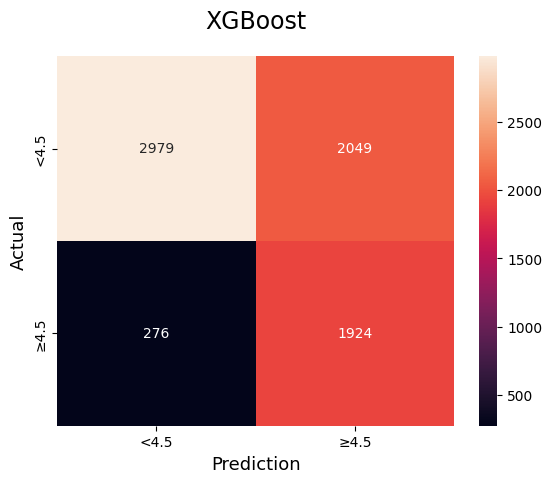

              precision    recall  f1-score   support

           0       0.92      0.59      0.72      5028
           1       0.48      0.87      0.62      2200

    accuracy                           0.68      7228
   macro avg       0.70      0.73      0.67      7228
weighted avg       0.78      0.68      0.69      7228

ROC-AUC: 0.8426252983293556


In [120]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='g', xticklabels=['<4.5', '≥4.5'], yticklabels=['<4.5', '≥4.5'])
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Prediction', fontsize=13)
plt.title('XGBoost', fontsize=17, pad=20)
plt.show()

report = classification_report(y_test, y_pred_xgb, output_dict=True)
recall_class_1_XGB = report['1']['recall']
roc_auc_XGB = roc_auc_score(y_test, y_prob_xgb)

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_XGB)


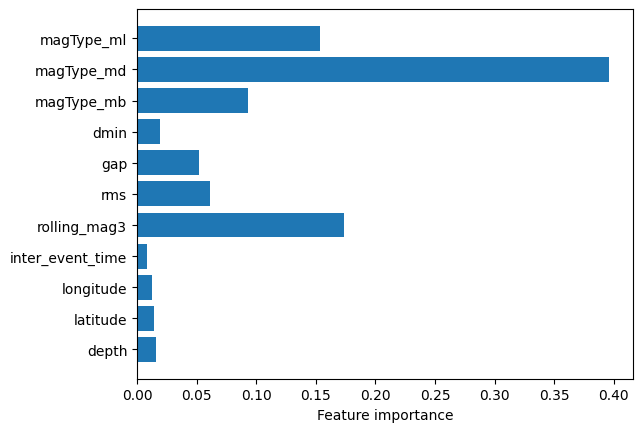

In [121]:
importances = xgb.feature_importances_
plt.barh(features, importances)
plt.xlabel("Feature importance")
plt.show()


For a magnitude threshold of 4.5, the XGBoost classifier achieved a ROC-AUC of 0.84. The model demonstrates strong ability to detect higher-magnitude earthquakes, with recall of 0.87 for class 1, while the precision for this class is lower (0.48), reflecting a trade-off between detecting most strong events and generating false positives. Conversely, smaller earthquakes (class 0) are predicted with high precision (0.92) but low recall (0.59). These results suggest that the classifier can be used effectively to identify potentially significant seismic events, although prediction of all events remains challenging due to the stochastic nature of earthquake occurrence.

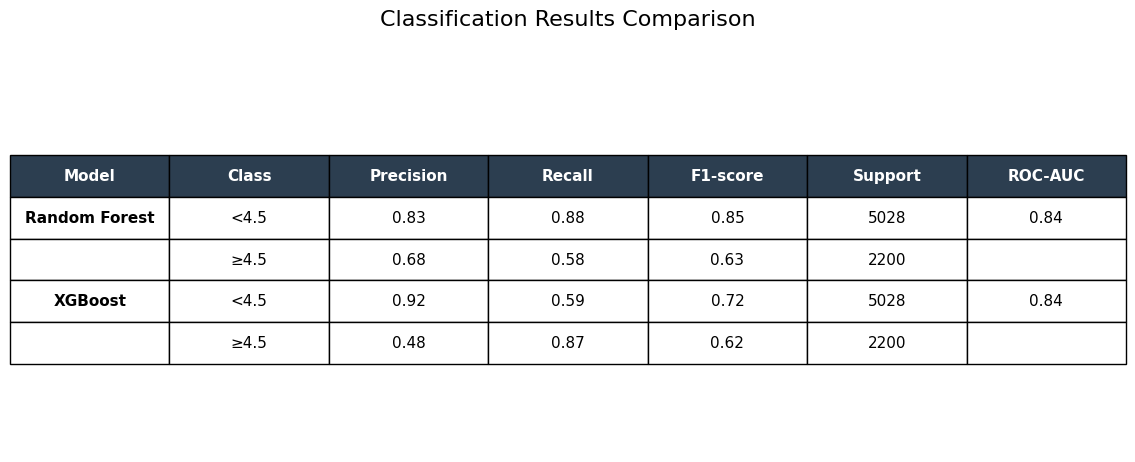

In [122]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score

def get_model_metrics(y_true, y_pred, y_prob, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    rows = []
    for cl in ['0', '1']:
        label = "<4.5" if cl == '0' else "≥4.5"
        rows.append({
            "Model": model_name if cl == '0' else "",
            "Class": label,
            "Precision": round(report[cl]['precision'], 2),
            "Recall": round(report[cl]['recall'], 2),
            "F1-score": round(report[cl]['f1-score'], 2),
            "Support": int(report[cl]['support']),
            "ROC-AUC": round(roc_auc, 2) if cl == '0' else ""
        })
    return rows

metrics_list = []
metrics_list.extend(get_model_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest"))
metrics_list.extend(get_model_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost"))

df_results = pd.DataFrame(metrics_list)

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=df_results.values, 
                 colLabels=df_results.columns, 
                 loc='center', 
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2c3e50')
    if col == 0 and row > 0:
        cell.set_text_props(weight='bold')

plt.title("Classification Results Comparison", fontsize=16, pad=30)
plt.show()

The comparison of Random Forest and XGBoost classifiers for predicting seismic events (threshold ≥4.5) shows that both models achieve an identical ROC-AUC of 0.84, indicating a strong overall ability to distinguish between classes. However, their predictive strategies differ significantly: XGBoost demonstrates a much higher Recall for significant events (0.87 vs. 0.58), making it more effective at capturing hazardous earthquakes. This comes at the cost of lower Precision (0.48), resulting in a higher rate of false alarms. In contrast, Random Forest provides a more balanced performance with higher reliability in its positive predictions. Overall, the Actual vs. Predicted plot confirms that while these classifiers improve detection, the moderate $R^2$ and the dispersion of data points highlight the inherent difficulty in predicting exact earthquake magnitudes due to seismic noise.

LSTM

In [123]:
import numpy as np
import pandas as pd

SEQ_LEN = 20
MAG_THRESHOLD = 4.5

features = ['mag', 'inter_event_time']

X_seq = []
y_seq = []

for i in range(SEQ_LEN, len(df)):
    X_seq.append(df[features].iloc[i-SEQ_LEN:i].values)
    y_seq.append(int(df['mag'].iloc[i] >= MAG_THRESHOLD))

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)


In [124]:
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]


In [125]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])) \
                .reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])) \
              .reshape(X_test.shape)


In [126]:
import torch
from torch.utils.data import Dataset, DataLoader

class SeismicDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SeismicDataset(X_train, y_train)
test_ds = SeismicDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)


In [127]:
import torch.nn as nn

class LSTMSeismic(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze()


In [128]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [129]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMSeismic(input_size=X_train.shape[2]).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | loss: {total_loss/len(train_loader):.4f}")


Epoch 1/30 | loss: 0.4271
Epoch 2/30 | loss: 0.4160
Epoch 3/30 | loss: 0.4141
Epoch 4/30 | loss: 0.4140
Epoch 5/30 | loss: 0.4133
Epoch 6/30 | loss: 0.4133
Epoch 7/30 | loss: 0.4134
Epoch 8/30 | loss: 0.4128
Epoch 9/30 | loss: 0.4123
Epoch 10/30 | loss: 0.4130
Epoch 11/30 | loss: 0.4120
Epoch 12/30 | loss: 0.4120
Epoch 13/30 | loss: 0.4118
Epoch 14/30 | loss: 0.4112
Epoch 15/30 | loss: 0.4113
Epoch 16/30 | loss: 0.4111
Epoch 17/30 | loss: 0.4109
Epoch 18/30 | loss: 0.4111
Epoch 19/30 | loss: 0.4109
Epoch 20/30 | loss: 0.4106
Epoch 21/30 | loss: 0.4102
Epoch 22/30 | loss: 0.4107
Epoch 23/30 | loss: 0.4106
Epoch 24/30 | loss: 0.4102
Epoch 25/30 | loss: 0.4104
Epoch 26/30 | loss: 0.4100
Epoch 27/30 | loss: 0.4097
Epoch 28/30 | loss: 0.4098
Epoch 29/30 | loss: 0.4096
Epoch 30/30 | loss: 0.4088


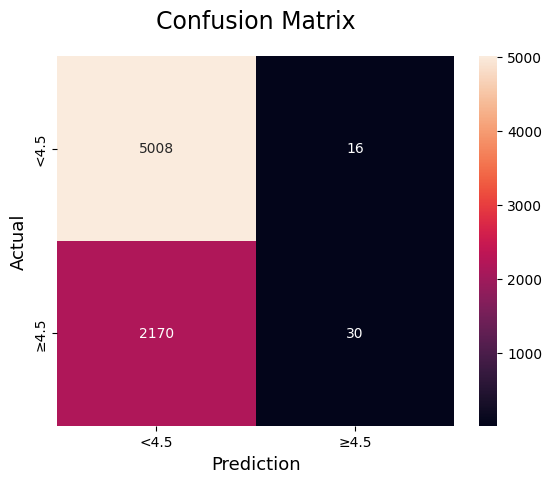

              precision    recall  f1-score   support

           0       0.70      1.00      0.82      5024
           1       0.65      0.01      0.03      2200

    accuracy                           0.70      7224
   macro avg       0.67      0.51      0.42      7224
weighted avg       0.68      0.70      0.58      7224

ROC-AUC: 0.5325294043138391


In [130]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

model.eval()
y_probs, y_true = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        preds = model(Xb).cpu().numpy()
        y_probs.extend(preds)
        y_true.extend(yb.numpy())

y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='g', xticklabels=['<4.5', '≥4.5'], yticklabels=['<4.5', '≥4.5'])
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Prediction', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.show()

report = classification_report(y_test, y_pred, output_dict=True)
recall_class_1_lstm = report['1']['recall']
roc_auc_lstm = roc_auc_score(y_true, y_probs)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_lstm)

The LSTM-based sequential model achieved poor classification performance, with a ROC-AUC score close to 0.5 and a recall of only 2% for strong earthquakes.
This indicates that the model failed to capture meaningful temporal dependencies in the earthquake catalog data.
In contrast, classical machine learning models such as Random Forest and XGBoost significantly outperformed the LSTM model.
These results suggest that earthquake catalogs alone do not contain sufficient temporal information for effective deep sequential modeling, and that strong earthquakes remain difficult to predict based solely on historical event sequences.

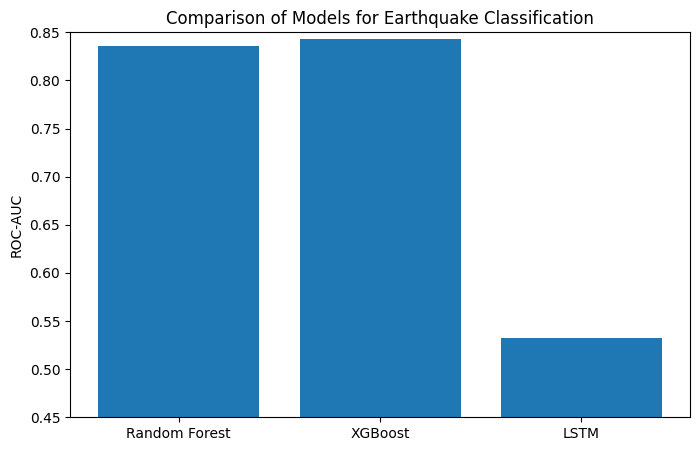

In [131]:
import matplotlib.pyplot as plt

models = [
    "Random Forest",
    "XGBoost",
    "LSTM"
]

roc_auc = [
    roc_auc_RF,
    roc_auc_XGB,
    roc_auc_lstm
]

plt.figure(figsize=(8,5))
plt.bar(models, roc_auc)
plt.ylabel("ROC-AUC")
plt.title("Comparison of Models for Earthquake Classification")
plt.ylim(0.45, 0.85)
plt.show()


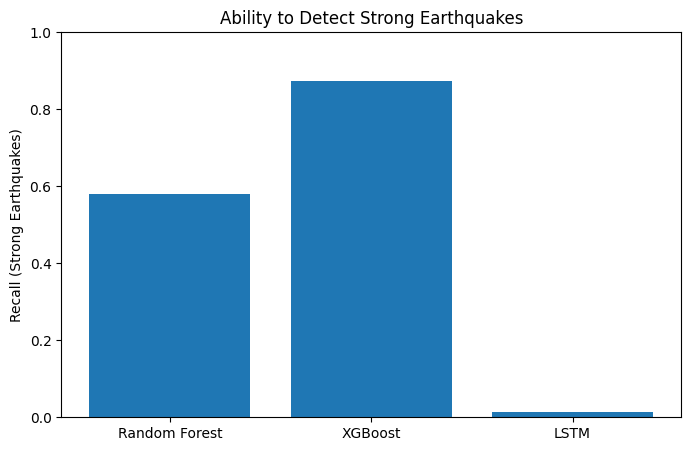

In [132]:
recall_1 = [
    recall_class_1_RF,
    recall_class_1_XGB,
    recall_class_1_lstm
]

plt.figure(figsize=(8,5))
plt.bar(models, recall_1)
plt.ylabel("Recall (Strong Earthquakes)")
plt.title("Ability to Detect Strong Earthquakes")
plt.ylim(0, 1)
plt.show()


A comparison of different modeling approaches shows that classical machine learning models, particularly Random Forest and XGBoost, outperform deep learning models in earthquake classification tasks based on catalog data.
Sequential deep learning models such as LSTM failed to capture meaningful temporal dependencies, achieving ROC-AUC scores close to random classification.
These results indicate that earthquake catalogs lack sufficient temporal structure for effective sequential modeling and that increased model complexity does not necessarily lead to improved predictive performance.